In [2]:
import zipfile

zip_file_path = '/content/dataset.zip'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('.')

print(f"Extracted contents of {zip_file_path} to the current directory.")

Extracted contents of /content/dataset.zip to the current directory.


Dataset: (200, 128, 128, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Round 1 ---
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 407ms/step - accuracy: 0.4630 - loss: 1.0935
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 509ms/step - accuracy: 0.4444 - loss: 0.7123
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 404ms/step - accuracy: 0.4630 - loss: 0.6951
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 752ms/step - accuracy: 0.4815 - loss: 0.7008
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 501ms/step - accuracy: 0.5741 - loss: 0.6935
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 378ms/step - accuracy: 0.4340 - loss: 1.1790
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 369ms/step - accuracy: 0.4717 - loss: 0.7134
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 656ms/step - accuracy: 0.5849 - loss: 0.6698
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 569ms/step - accuracy: 0.5660 - loss: 0.6720
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step - accuracy: 0.6604 - loss: 0.6597
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 378ms/step - accuracy: 0.5472 - loss: 0.8710
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step - accuracy: 0.5283 - 

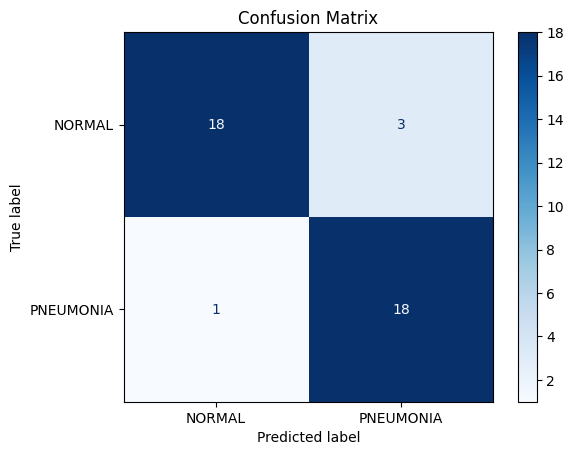

In [3]:
import numpy as np
import cv2
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import hmac
import hashlib
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================================================
# 🔐 HMAC SECRET KEY
# =========================================================
SECRET_KEY = b"secure_shared_key"

def generate_hmac(data, key):
    message = pickle.dumps(data)
    return hmac.new(key, message, hashlib.sha256).hexdigest()

def verify_hmac(data, received_hmac, key):
    expected = generate_hmac(data, key)
    return hmac.compare_digest(expected, received_hmac)

# =========================================================
# ===== PATH =====
# =========================================================
base = "dataset"
IMG_SIZE = 128

# =========================================================
# ===== LOAD DATA =====
# =========================================================
def load_data():
    data, labels = [], []

    for label, cls in enumerate(["NORMAL", "PNEUMONIA"]):
        folder = os.path.join(base, cls)

        for img_name in os.listdir(folder)[:300]:
            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

            data.append(img)
            labels.append(label)

    return np.array(data), np.array(labels)

X, y = load_data()
print("Dataset:", X.shape)

# =========================================================
# ===== SPLIT =====
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# ===== CLIENT SPLIT =====
# =========================================================
X1, X_temp, y1, y_temp = train_test_split(X_train, y_train, test_size=0.66)
X2, X3, y2, y3 = train_test_split(X_temp, y_temp, test_size=0.5)

clients = [(X1,y1), (X2,y2), (X3,y3)]

# =========================================================
# ===== DATA AUGMENTATION =====
# =========================================================
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# =========================================================
# ===== MODEL =====
# =========================================================
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# =========================================================
# ===== FEDERATED AVG =====
# =========================================================
def federated_avg(weights):
    avg = []
    for layer in zip(*weights):
        avg.append(np.mean(layer, axis=0))
    return avg

# =========================================================
# ===== TRAINING =====
# =========================================================
global_model = create_model()
history = []

ROUNDS = 3

for r in range(ROUNDS):
    print(f"\n--- Round {r+1} ---")

    local_weights = []

    for i in range(3):
        model = create_model()
        model.set_weights(global_model.get_weights())

        X_local, y_local = clients[i]

        model.fit(datagen.flow(X_local, y_local, batch_size=16),
                  epochs=5, verbose=1)

        weights = model.get_weights()

        # 🔐 Generate HMAC
        signature = generate_hmac(weights, SECRET_KEY)

        # Send weights + signature
        local_weights.append((weights, signature))

    # =====================================================
    # 🔐 VERIFY CLIENT UPDATES
    # =====================================================
    verified_weights = []

    for weights, signature in local_weights:
        if verify_hmac(weights, signature, SECRET_KEY):
            verified_weights.append(weights)
        else:
            print("⚠️ Tampered client detected!")

    if len(verified_weights) == 0:
        print("❌ No valid clients!")
        break

    # Aggregate only verified weights
    global_model.set_weights(federated_avg(verified_weights))

    loss, acc = global_model.evaluate(X_test, y_test, verbose=0)
    history.append(acc)

    print("Global Accuracy:", acc)

# =========================================================
# ===== FINAL METRICS =====
# =========================================================
final_loss, final_accuracy = global_model.evaluate(X_test, y_test, verbose=0)

y_pred = global_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== FINAL RESULTS =====")
print("Final Accuracy :", final_accuracy)
print("Precision      :", precision)
print("Recall         :", recall)
print("F1 Score       :", f1)

print("\n===== FINAL RESULTS =====")

print("Final Accuracy : {:.2f}%".format(final_accuracy * 100))
print("Precision      : {:.2f}%".format(precision * 100))
print("Recall         : {:.2f}%".format(recall * 100))
print("F1 Score       : {:.2f}%".format(f1 * 100))

# =========================================================
# ===== CONFUSION MATRIX =====
# =========================================================
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["NORMAL","PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')